In [1]:

import numpy as np
import tensorflow.compat.v1 as tf



In [2]:
import magenta
from magenta.models.rl_tuner import rl_tuner
from magenta.models.rl_tuner import rl_tuner_ops

In [3]:
tf.disable_v2_behavior()

SAVE_PATH = "/Users/asaha/Documents/Stanford/projects/music_rl_output"

Instructions for updating:
non-resource variables are not supported in the long term


In [4]:
ALGORITHM = 'q'
REWARD_SCALER = 1
OUTPUT_EVERY_NTH = 50000
NUM_NOTES_IN_COMPOSITION = 32
PRIME_WITH_MIDI = False

In [5]:
import magenta
rl_tuner_hparams = magenta.contrib.training.HParams(random_action_probability=0.1,
                                               store_every_nth=1,
                                               train_every_nth=5,
                                               minibatch_size=32,
                                               discount_rate=0.5,
                                               max_experience=100000,
                                               target_network_update_rate=0.01)

In [6]:
rl_tuner.reload_files()

In [7]:
rl_net = rl_tuner.RLTuner(SAVE_PATH, 
                          dqn_hparams=rl_tuner_hparams, 
                          algorithm=ALGORITHM,
                          reward_scaler=REWARD_SCALER,
                          output_every_nth=OUTPUT_EVERY_NTH,
                          num_notes_in_melody=NUM_NOTES_IN_COMPOSITION)

Retrieving checkpoint of Note RNN from Magenta download server.
INFO:tensorflow:Initializing q network
INFO:tensorflow:Using custom hparams
INFO:tensorflow:Initializing melody RNN graph for scope q_network
Instructions for updating:
Please use `keras.layers.RNN(cell)`, which is equivalent to this API
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
INFO:tensorflow:Initializing target q network
INFO:tensorflow:Using custom hparams
INFO:tensorflow:Initializing melody RNN graph for scope target_q_network
INFO:tensorflow:Initializing reward network
INFO:tensorflow:Using custom hparams
INFO:tensorflow:Initializing melody RNN graph for scope reward_rnn
INFO:tensorflow:Q network cell: <keras.src.layers.rnn.legacy_cells.MultiRNNCell object at 0x3140c9900>
INFO:tensorflow:Adding RL graph variables
INFO:tensorflow:Adding reward computation portion of the graph
INFO:tensorflow:Adding taking action portion of graph


/Users/asaha/Documents/Stanford/projects/magenta/magenta/models/rl_tuner/rl_tuner_ops.py:312: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.nn.rnn_cell.LSTMCell(num_units, state_is_tuple=state_is_tuple)


Instructions for updating:
Use the `axis` argument instead
INFO:tensorflow:Add estimating future rewards portion of graph
INFO:tensorflow:Adding q value prediction portion of graph
INFO:tensorflow:Summary name q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/kernel:0 is illegal; using q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/kernel_0 instead.
INFO:tensorflow:Summary name q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/kernel:0/gradients is illegal; using q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/kernel_0/gradients instead.
INFO:tensorflow:Summary name q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/bias:0 is illegal; using q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/bias_0 instead.
INFO:tensorflow:Summary name q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/bias:0/gradients is illegal; using q_network/rnn/multi_rnn_cell/cell_0/lstm_cell/bias_0/gradients instead.
INFO:tensorflow:Summary name q_network/fully_connected/weights:0 is illegal; using q_network/fully_connected/weights_0 inst

2025-03-18 11:58:09.397303: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:375] MLIR V1 optimization pass is not enabled


INFO:tensorflow:Priming with note 20
INFO:tensorflow:Generated sequence: [0, 20, 0, 20, 0, 0, 0, 20, 0, 20, 0, 20, 0, 0, 0, 0, 0, 20, 0, 0, 0, 22, 0, 20, 0, 20, 0, 0, 0, 0, 0, 22]
Generated sequence: [0, 20, 0, 20, 0, 0, 0, 20, 0, 20, 0, 20, 0, 0, 0, 0, 0, 20, 0, 0, 0, 22, 0, 20, 0, 20, 0, 0, 0, 0, 0, 22]
INFO:tensorflow:Wrote a melody to /Users/asaha/Documents/Stanford/projects/music_rl_output
INFO:tensorflow:Visualizing note selection probabilities:


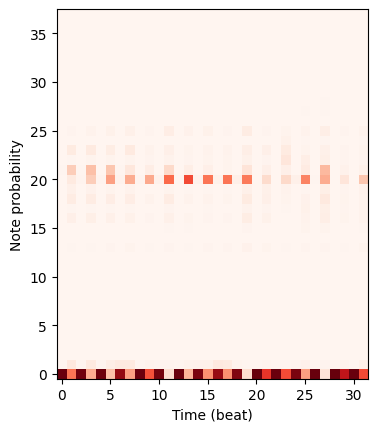

In [9]:
rl_net.generate_music_sequence(visualize_probs=True, title='pre_rl', length=32)

In [13]:
rl_net.train(num_steps=200000, exploration_period=100000)

INFO:tensorflow:Evaluating initial model...
INFO:tensorflow:Evaluating model...
INFO:tensorflow:Training iteration 50000
INFO:tensorflow:	Reward for last 50000 steps: -386207.5058602818
INFO:tensorflow:		Music theory reward: -33022.053969589426
INFO:tensorflow:		Note RNN reward: -353185.451890707
Training iteration 50000
	Reward for last 50000 steps: -386207.5058602818
		Music theory reward: -33022.053969589426
		Note RNN reward: -353185.451890707
INFO:tensorflow:	Exploration probability is 0.521191
INFO:tensorflow:Evaluating model...
Instructions for updating:
Use standard file APIs to delete files with this prefix.
INFO:tensorflow:Training iteration 100000
INFO:tensorflow:	Reward for last 50000 steps: -157165.7978272149
INFO:tensorflow:		Music theory reward: 2429.9544141566967
INFO:tensorflow:		Note RNN reward: -159595.75224137306
Training iteration 100000
	Reward for last 50000 steps: -157165.7978272149
		Music theory reward: 2429.9544141566967
		Note RNN reward: -159595.75224137306

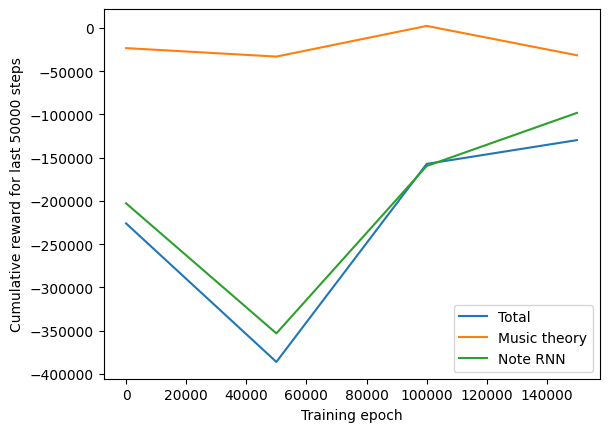

In [14]:
rl_net.plot_rewards()

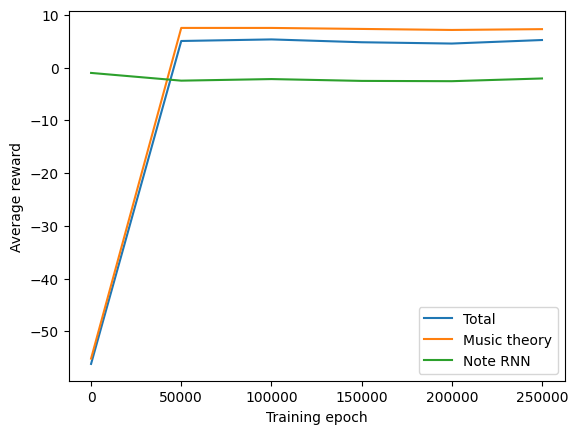

In [15]:
rl_net.plot_evaluation()

INFO:tensorflow:Priming with note 6
INFO:tensorflow:Generated sequence: [0, 19, 0, 1, 0, 19, 1, 23, 21, 0, 25, 26, 0, 1, 0, 23, 0, 0, 18, 21, 0, 0, 21, 0, 1, 0, 23, 0, 1, 25, 26, 0]
Generated sequence: [0, 19, 0, 1, 0, 19, 1, 23, 21, 0, 25, 26, 0, 1, 0, 23, 0, 0, 18, 21, 0, 0, 21, 0, 1, 0, 23, 0, 1, 25, 26, 0]
INFO:tensorflow:Wrote a melody to /Users/asaha/Documents/Stanford/projects/music_rl/output
INFO:tensorflow:Visualizing note selection probabilities:


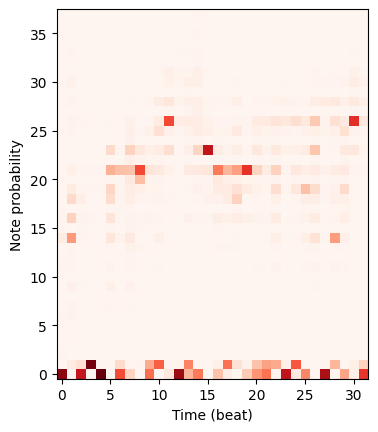

In [16]:
rl_net.generate_music_sequence(visualize_probs=True, title='post_rl')

In [19]:
rl_net.save_model('rl_trained_model')

In [20]:
stat_dict = rl_net.evaluate_music_theory_metrics(num_compositions=100)

INFO:tensorflow:Total compositions: 100.0
Total notes:3200.0
	Compositions starting with tonic: 7.0
	Compositions with unique highest note:56.0
	Compositions with unique lowest note:58.0
	Number of resolved leaps:39.0
	Number of double leaps:19.0
	Notes not in key:134.0
	Notes in motif:1840.0
	Notes in repeated motif:0.0
	Notes excessively repeated:5.0

	Percent compositions starting with tonic:0.07
	Percent compositions with unique highest note:0.56
	Percent compositions with unique lowest note:0.58
	Percent of leaps resolved:0.6724137931034483
	Percent notes not in key:0.041875
	Percent notes in motif:0.575
	Percent notes in repeated motif:0.0
	Percent notes excessively repeated:0.0015625

	Average autocorrelation of lag1:-0.11073908562381324
	Average autocorrelation of lag2:-0.02984955331681912
	Average autocorrelation of lag3:-0.04091983761791397

	Avg. num octave jumps per composition:0.08
	Avg. num sevenths per composition:0.05
	Avg. num fifths per composition:0.48
	Avg. num sixt

In [29]:
from IPython.display import Audio
from pretty_midi import PrettyMIDI

music = PrettyMIDI(midi_file='/Users/asaha/Documents/Stanford/projects/music_rl/output/pre_rl.mid')
waveform = music.fluidsynth()
Audio(waveform, rate=44100)

In [30]:
len(waveform) / 44100

7.0

Changing working directory to: `/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21'
Processing `/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmpvdue2bqi.ly'
Parsing...
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmpvdue2bqi.ly:50:5: error: unknown escaped string: `\RemoveEmptyStaffContext'
    
    \RemoveEmptyStaffContext
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmpvdue2bqi.ly:51:5: error: syntax error, unexpected \override, expecting '='
    
    \override VerticalAxisGroup #'remove-first = ##t
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmpvdue2bqi.ly:51:33: warning: deprecated: missing `.' in property path VerticalAxisGroup.remove-first
    \override VerticalAxisGroup 
                                #'remove-first = ##t
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmpvdue2bqi.ly:53:2: error: syntax error, unexpected '}'
 
 }
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmpvdue2bqi.ly:53:3: error: U

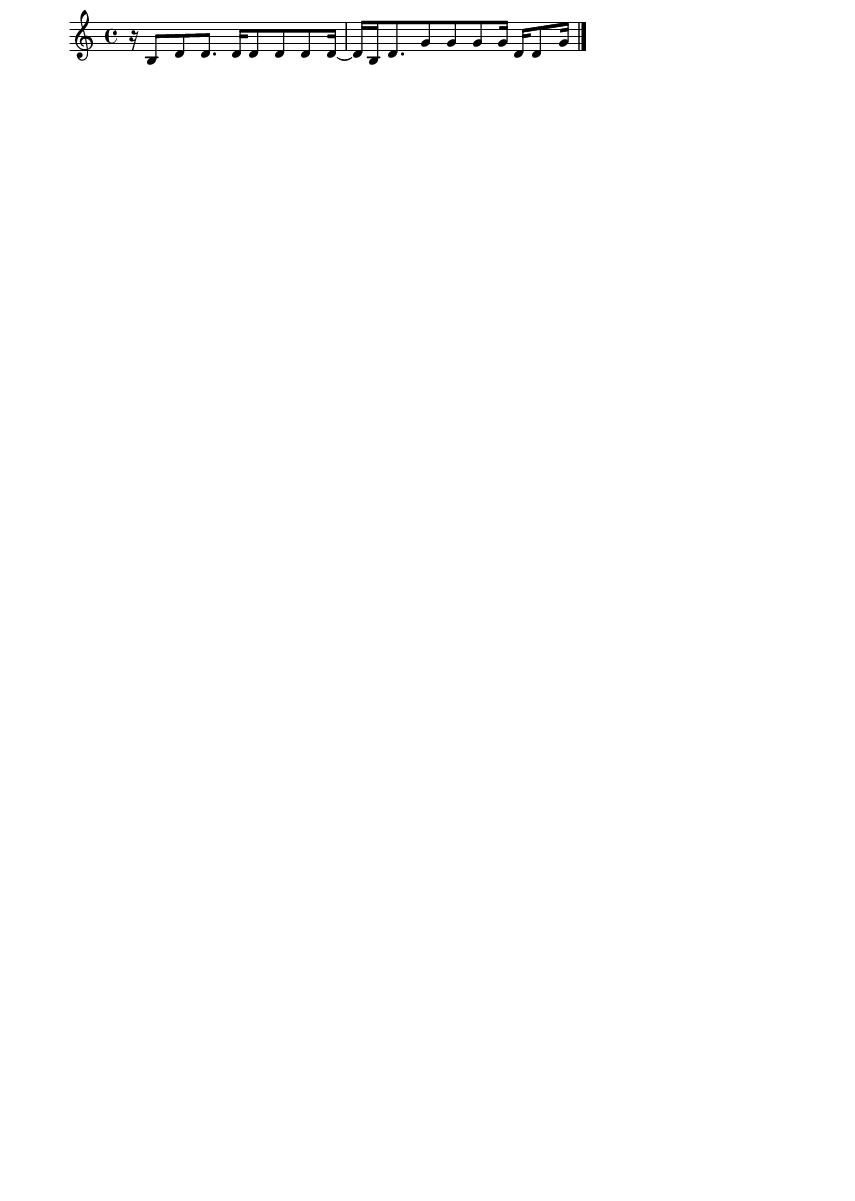

In [47]:
from music21 import converter
s = converter.parse('/Users/asaha/Documents/Stanford/projects/music_rl/output/pre_rl.mid')
from IPython.display import Image
Image(filename=s.write('lily.png'))

In [35]:
s.duration

<music21.duration.Duration 8.0>

In [ ]:
s = converter.parse('/Users/asaha/Documents/Stanford/projects/q/q.mid')
Image(filename=s.write('lily.png'))

Changing working directory to: `/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21'
Processing `/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmpph5fdisy.ly'
Parsing...
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmpph5fdisy.ly:25:5: error: unknown escaped string: `\RemoveEmptyStaffContext'
    
    \RemoveEmptyStaffContext
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmpph5fdisy.ly:26:5: error: syntax error, unexpected \override, expecting '='
    
    \override VerticalAxisGroup #'remove-first = ##t
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmpph5fdisy.ly:26:33: warning: deprecated: missing `.' in property path VerticalAxisGroup.remove-first
    \override VerticalAxisGroup 
                                #'remove-first = ##t
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmpph5fdisy.ly:28:2: error: syntax error, unexpected '}'
 
 }
/var/folders/s6/mwrbbn353110_xfh8jbtl_f00000gn/T/music21/tmpph5fdisy.ly:28:3: error: U

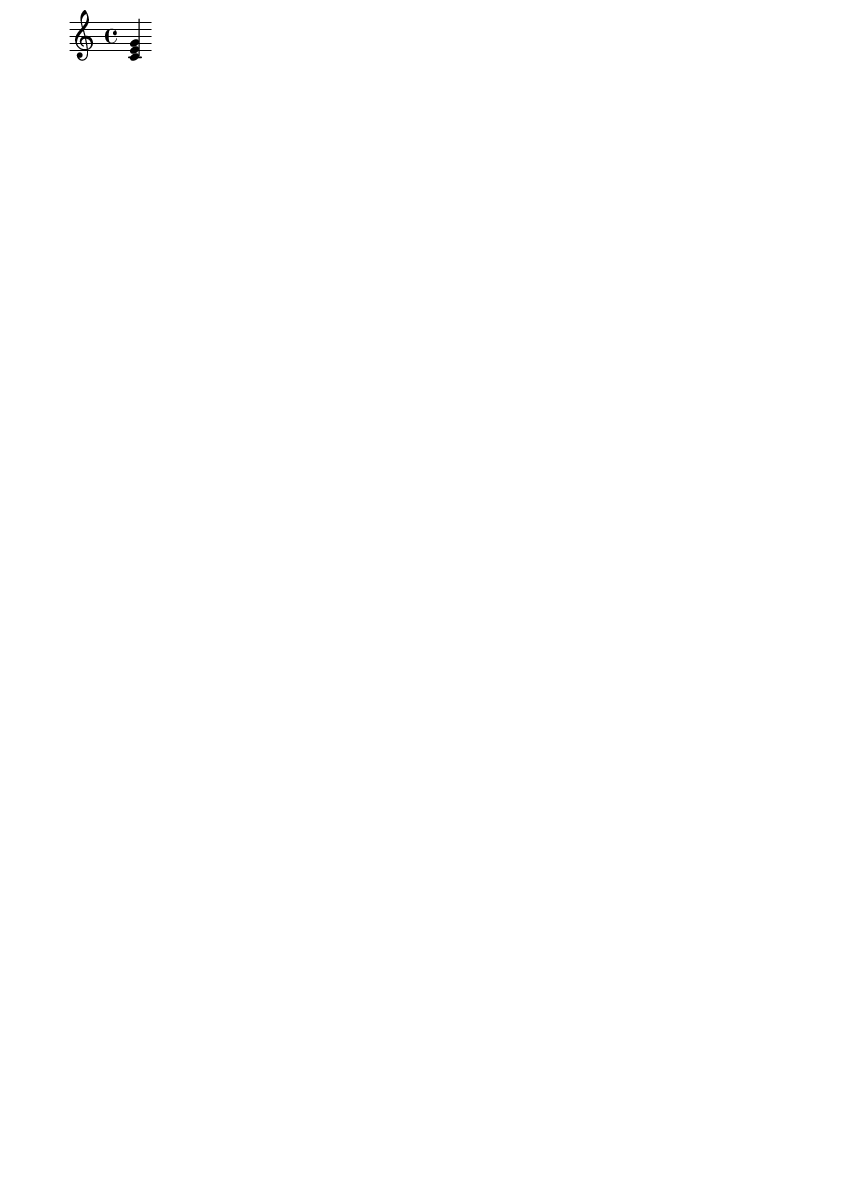

In [19]:
from music21 import *
c = chord.Chord("C4 E4 G4")
c.isConsonant()
Image(filename=c.write('lily.png'))